In [ ]:
from frb.surveys import survey_utils as su
from frb.surveys import catalog_utils as cu

import os
import tqdm

from astropy import visualization as vis
from astropy.wcs import WCS
from astropy.stats import sigma_clipped_stats
from astropy.table import Table, vstack
from astropy.coordinates import SkyCoord
from astropy import units as u

import numpy as np
import matplotlib.pyplot as plt

from sparcl.client import SparclClient

from scipy.signal import medfilt
from scipy.interpolate import interp1d, UnivariateSpline

from gotoq import core as gtq

import legacystamps

from importlib import reload

/home/sunil/miniconda3/lib/python3.13/site-packages/requests/__init__.py:109: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.2.0)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(


# Finding GOTOQ candidates in DESI

## Get UV-bright QSOs first

In [ ]:
# Download the DESI QSO catalog
reload(gtq)
desi_qsos = gtq.get_desi_qso_table(overwrite=False)

File already exists. Set overwrite=True to overwrite it.


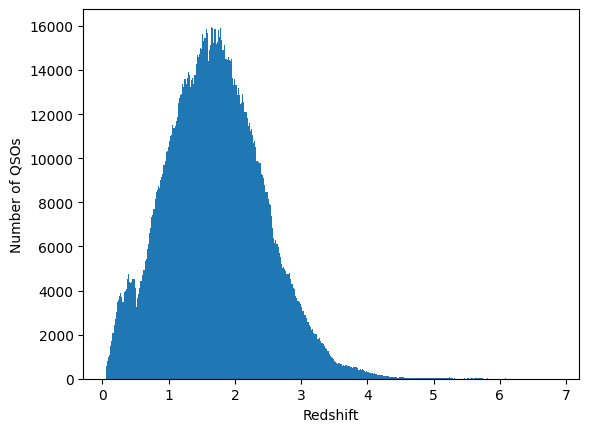

In [4]:
plt.hist(desi_qsos['DESI_z'], bins='auto')
plt.xlabel("Redshift")
plt.ylabel("Number of QSOs")
plt.show()

In [4]:
# Similar search but I ran the query on CASJobs for a faster reponse
# import mastcasjobs as mcj
# import os

# Query
query_str = """
                SELECT 
                    p.objid, p.ra, p.dec, p.nuv_mag, p.nuv_magerr, p.fuv_mag, p.fuv_magerr, pe.mpstype AS survey
                FROM
                    photoobjall AS p, photoextract AS pe
                INTO
                    mydb.galex_fuv_bright_sources
                WHERE
                    p.photoextractid=pe.photoextractid AND p.fuv_mag<18.5
            """
# # Execute
# user = os.getenv('MAST_CASJOBS_USER')
# pwd = os.getenv('MAST_CASJOBS_PWD')

# job = mcj.MastCasJobs(context="GALEX_GR6Plus7", username=user, password=pwd)
# galex_tab = job.submit(query_str, task_name="Galex FUV bright sources")
# galex_tab

galex_tab = Table.read("galex_bright.csv", format="csv")

In [5]:
# Cross match
matched_qso, matched_galex = cu.xmatch_catalogs(desi_qsos, galex_tab, dist=2*u.arcsec)

idx, d2d, _= cu.xmatch_catalogs(desi_qsos, galex_tab,
                              dist=2*u.arcsec, return_match_idx=True)

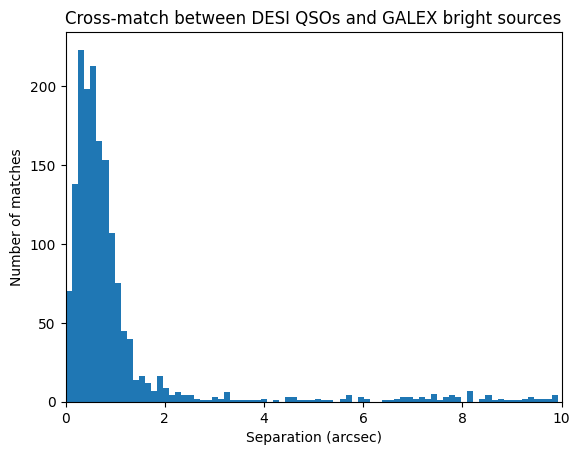

In [6]:
limit = 10*u.arcsec
plt.hist(d2d.arcsec[d2d<limit], bins='auto')
plt.xlabel("Separation (arcsec)")
plt.ylabel("Number of matches")
plt.title("Cross-match between DESI QSOs and GALEX bright sources")
plt.xlim(0, 10)
plt.show()

In [7]:
matched_qso['GALEX_FUV_MAG'] = matched_galex['fuv_mag']
matched_qso.sort(['DESI_z','ra', 'dec'])
matched_qso

DESI_ID,ra,dec,DESI_z,DESI_z_err,DESI_survey,desi_zcat_primary,DESI_z_warn,GALEX_FUV_MAG
int64,float64,float64,float64,float64,str7,str1,int64,float64
2305843021695943910,195.0832434173324,61.65503651806954,0.05222483039988823,4.65412308321073e-06,main,t,0,17.9436645507813
2305843018785096852,215.5841609635079,29.71528178124287,0.05292468469785445,4.831989425569241e-06,main,t,0,17.2959899902344
39628475996311491,215.5841686862564,29.71527221044749,0.05294380517822361,5.133627535689339e-06,main,t,0,17.2959899902344
39632985812635075,181.4577967237062,35.17944933617638,0.05377199939710087,2.640120139863352e-06,main,t,0,17.4759922027588
2305843039236528742,181.4577658596346,35.17940421767707,0.05378324654978045,2.810581107846241e-06,main,t,0,17.4759922027588
2305843036527004194,214.1284010004999,1.618935536294424,0.05419148179005401,5.844902670447806e-06,main,t,0,17.8516368865967
39627824557984211,214.1283944026409,1.618923761297891,0.05422736428114017,6.700759245033133e-06,main,t,0,17.8516368865967
2305843020412486280,206.1100827938952,44.27222139073776,0.0549346510470639,4.122752226436085e-06,main,t,0,17.4355182647705
39633259839097338,196.4458800977272,50.67614746766068,0.05537880126489214,3.082500251422336e-06,main,t,0,17.9577655792236


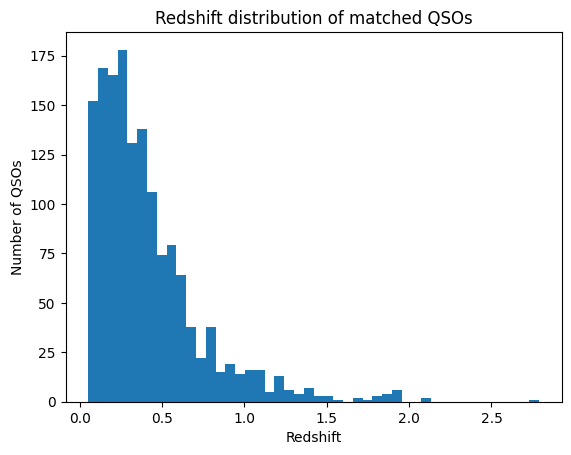

In [8]:
plt.hist(matched_qso['DESI_z'], bins='auto')
plt.xlabel("Redshift")
plt.ylabel("Number of QSOs")
plt.title("Redshift distribution of matched QSOs")
plt.show()


## Search for extended sources in the Legacy Survey near the UV bright quasars

In [ ]:
# TODO: This can be sped up in a variety of ways, e.g. by doing bulk queries to the survey instead of one query per source, or by parallelizing the queries. But for now this is good enough. Takes about 10 min for the 1500 sources in the matched_qso table.

master_tab = []
os.makedirs("desi_qso_cutouts/png", exist_ok=True)

def make_cutout_png(img, hdr, save_path, title=None, cmap='gray'):
    plt.figure(figsize=(5,5))
    wcs = WCS(hdr)
    _, med, std = sigma_clipped_stats(img, sigma=3.0)
    norm = vis.ImageNormalize(vmin=med - std, vmax=med+100*std, stretch=vis.LogStretch())
    _, ax = plt.subplots(subplot_kw={'projection': wcs})
    ax.imshow(img, origin='lower', cmap=cmap, norm=norm)
    if title is not None:
        ax.set_title(title)
    else:
        ax.set_title('DESI QSO Cutout')
    ax.set_xlabel('R.A.')
    ax.set_ylabel('Dec.')
    plt.savefig(save_path)
    plt.close()

for entry in tqdm.tqdm(matched_qso):
    qso_coord = SkyCoord(ra=entry['ra']*u.degree, dec=entry['dec']*u.degree)
    survey = su.load_survey_by_name('DECaL', coord = qso_coord,
                                    radius=1*u.arcsec)
    cat = survey.get_catalog()
    if cat != None and len(cat)>0:
        cat['survey'] = cat['survey'].astype(str) # Convert from int to string
        cat['ang_dist_arcsec'] = qso_coord.separation(SkyCoord(ra=cat['ra']*u.degree, dec=cat['dec']*u.degree)).arcsec
        cat['DESI_QSO_ID'] = entry['DESI_ID']
        cat['QSO_z'] = entry['DESI_z']
        cat['QSO_ra'] = entry['ra']
        cat['QSO_dec'] = entry['dec']
        cat['QSO_zcat_primary'] = entry['desi_zcat_primary']
        # Weed out AGN hosts
        cat = cat[cat['ang_dist_arcsec']>0.2]
        if len(cat) > 0:
            # Save 30'' cutout around the QSO
            img, hdr = survey.get_cutout(imsize=30*u.arcsec, band='g')
            if img is not None:
                # fits.HDUList([fits.PrimaryHDU(img, header=hdr)]).writeto(f"desi_qso_cutouts/fits/{entry['DESI_ID']}_g_cutout.fits", overwrite=True)
                make_cutout_png(img, hdr,
                            save_path = f"desi_qso_cutouts/png/{entry['DESI_ID']}_g_cutout.png",
                            title=f"{entry['DESI_ID']}.\n z = {entry['DESI_z']:.4f}",
                            cmap="Greens")
            master_tab.append(cat)
master_tab = vstack(master_tab)
master_tab

  1%|▏         | 22/1495 [00:10<14:29,  1.69it/s]

downloading deepest stacked image...


  2%|▏         | 29/1495 [00:14<13:27,  1.81it/s]

No image available


  2%|▏         | 34/1495 [00:17<15:12,  1.60it/s]

...

<Figure size 500x500 with 0 Axes>

<Figure size 500x500 with 0 Axes>

<Figure size 500x500 with 0 Axes>

<Figure size 500x500 with 0 Axes>

<Figure size 500x500 with 0 Axes>

In [9]:
master_tab.write("desi_fuv_bright_qsosxdecals.csv",
                 format="csv", overwrite=True)

NameError: name 'master_tab' is not defined

In [10]:
master_tab = Table.read("desi_fuv_bright_qsosxdecals.csv")
master_tab

z_phot_median,z_spec,survey,z_phot_l68,z_phot_u68,z_phot_l95,z_phot_u95,DECaL_g,DECaL_g_err,DECaL_r,DECaL_r_err,DECaL_z,DECaL_z_err,DECaL_ID,ra,dec,DECaL_brick,DECaL_type,ang_dist_arcsec,DESI_QSO_ID,QSO_z,QSO_ra,QSO_dec,QSO_zcat_primary
float64,float64,str12,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,float64,float64,int64,str3,float64,int64,float64,float64,float64,str1
-99.0,-99.0,0,-99.0,-99.0,-99.0,-99.0,inf,-99.0,inf,-99.0,inf,-99.0,10995285856627988,60.8224347583426,-30.80265624148841,161723,DUP,0.22268510350456136,39627077380478213,0.06021425093413554,60.82249450478776,-30.80269077711849,t
0.0,0.0,0,0.0,0.0,0.0,0.0,inf,-99.0,inf,-99.0,inf,-99.0,9907736773728714,276.036924216698,46.67144082816393,572141,DUP,0.3034161508799949,39633196844843692,0.06727721312898165,276.0370113354671,46.67138141488419,t
0.0,0.0,0,0.0,0.0,0.0,0.0,inf,-99.0,inf,-99.0,inf,-99.0,9907735122022198,211.4349126186789,40.8546759397456,546938,DUP,0.20232097433052426,39633091135801270,0.0689609958357119,211.4348909207135,40.85462218915677,t
0.14052391,-99.0,0,0.12753908,0.20377657,0.11511756,0.23966165,18.144653,0.002302894337054376,17.075054,0.0011619800972635585,16.342579,0.001640983044560114,10995382040397294,44.45908370533046,-13.62205279228881,253451,REX,0.9138578405714194,39627462115591549,0.07938954953001134,44.45889084913347,-13.62222399122559,t
1.3200364,-99.0,0,1.02475,2.1225,0.20098351,3.094,16.839113,0.0006710030250772922,16.277458,0.00046201781181239157,16.204336,0.0005627755103256479,10995449935692524,198.2736944868796,-2.177562433222156,318201,PSF,0.26249653136311735,39627733696774753,0.08392724279681994,198.2737110257711,-2.177633451246343,t
0.13900703,-99.0,0,0.11412802,0.1524725,0.07437011,0.16282845,17.825546,0.0023632966691936167,16.96331,0.001215450740484619,16.194752,0.001303949179149183,10995449935692521,198.2736872679989,-2.177636165221093,318201,SER,0.25294766925779905,2305843036665420325,0.08393393421123704,198.2736991220644,-2.177566907679187,t
0.10349255,0.0837119,SDSS-QSO,0.044985335,0.29502645,0.017501043,0.8758217,16.505796,0.0004147566612738445,16.098377,0.00039196046712172586,15.855209,0.00035594432087526816,10995467076772112,325.2273119258847,0.4272777140861873,334548,PSF,0.6073987745038502,39627802261070020,0.08414099665397623,325.2271927768246,0.427158251271244,t
-99.0,-99.0,-99.0,-99.0,-99.0,-99.0,-99.0,inf,-99.0,inf,-99.0,inf,-99.0,10995471154687737,217.2773834592692,1.285042885023844,338437,DUP,0.22568104797787564,39627818572710520,0.08679450731841636,217.2774225264296,1.284993849752379,t
0.0412962,0.08644326,DESI-SV3-BGS,0.03087121,0.08463402,0.018868916,0.1854191,15.21699,0.0002412481222569736,14.720485,0.00021889353049470294,14.418016,0.0002602113578062607,10995471154677033,217.277400423662,1.284988063583495,338437,SER,0.21957012777480142,2305843036438935891,0.08683103478492642,217.2773883640328,1.285047851761408,t


In [11]:
# Sources whose type is not PSF
extended_sources = master_tab[master_tab['DECaL_type'] != 'PSF']
extended_sources

z_phot_median,z_spec,survey,z_phot_l68,z_phot_u68,z_phot_l95,z_phot_u95,DECaL_g,DECaL_g_err,DECaL_r,DECaL_r_err,DECaL_z,DECaL_z_err,DECaL_ID,ra,dec,DECaL_brick,DECaL_type,ang_dist_arcsec,DESI_QSO_ID,QSO_z,QSO_ra,QSO_dec,QSO_zcat_primary
float64,float64,str12,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,float64,float64,int64,str3,float64,int64,float64,float64,float64,str1
-99.0,-99.0,0,-99.0,-99.0,-99.0,-99.0,inf,-99.0,inf,-99.0,inf,-99.0,10995285856627988,60.8224347583426,-30.80265624148841,161723,DUP,0.22268510350456136,39627077380478213,0.06021425093413554,60.82249450478776,-30.80269077711849,t
0.0,0.0,0,0.0,0.0,0.0,0.0,inf,-99.0,inf,-99.0,inf,-99.0,9907736773728714,276.036924216698,46.67144082816393,572141,DUP,0.3034161508799949,39633196844843692,0.06727721312898165,276.0370113354671,46.67138141488419,t
0.0,0.0,0,0.0,0.0,0.0,0.0,inf,-99.0,inf,-99.0,inf,-99.0,9907735122022198,211.4349126186789,40.8546759397456,546938,DUP,0.20232097433052426,39633091135801270,0.0689609958357119,211.4348909207135,40.85462218915677,t
0.14052391,-99.0,0,0.12753908,0.20377657,0.11511756,0.23966165,18.144653,0.002302894337054376,17.075054,0.0011619800972635585,16.342579,0.001640983044560114,10995382040397294,44.45908370533046,-13.62205279228881,253451,REX,0.9138578405714194,39627462115591549,0.07938954953001134,44.45889084913347,-13.62222399122559,t
0.13900703,-99.0,0,0.11412802,0.1524725,0.07437011,0.16282845,17.825546,0.0023632966691936167,16.96331,0.001215450740484619,16.194752,0.001303949179149183,10995449935692521,198.2736872679989,-2.177636165221093,318201,SER,0.25294766925779905,2305843036665420325,0.08393393421123704,198.2736991220644,-2.177566907679187,t
-99.0,-99.0,-99.0,-99.0,-99.0,-99.0,-99.0,inf,-99.0,inf,-99.0,inf,-99.0,10995471154687737,217.2773834592692,1.285042885023844,338437,DUP,0.22568104797787564,39627818572710520,0.08679450731841636,217.2774225264296,1.284993849752379,t
0.0412962,0.08644326,DESI-SV3-BGS,0.03087121,0.08463402,0.018868916,0.1854191,15.21699,0.0002412481222569736,14.720485,0.00021889353049470294,14.418016,0.0002602113578062607,10995471154677033,217.277400423662,1.284988063583495,338437,SER,0.21957012777480142,2305843036438935891,0.08683103478492642,217.2773883640328,1.285047851761408,t
-99.0,-99.0,-99.0,-99.0,-99.0,-99.0,-99.0,inf,-99.0,inf,-99.0,inf,-99.0,10995471154687737,217.2773834592692,1.285042885023844,338437,DUP,0.20584839698472587,2851353646858240,0.0868865411835696,217.2773938175643,1.284986650473131,t
0.32419217,-99.0,-99.0,0.077371016,0.40082055,0.012035911,0.44406193,-99.0,-99.0,18.999905,0.00600399794035646,-99.0,-99.0,10995440846638012,190.0800414122187,-3.822020082118954,309533,EXP,0.9739579762204507,39627697340548751,0.09202882039563415,190.0803071189289,-3.822074004575822,t


In [12]:
# Foreground according to DECaL photo-z?
# Not to be trusted but worth looking into
photoz_foreground = extended_sources[(extended_sources['z_phot_median'] < extended_sources['QSO_z']) & (extended_sources['z_phot_median'] > 0)]
photoz_foreground = photoz_foreground[photoz_foreground['QSO_z'] > 0.1] # Keep only extended sources
photoz_foreground

z_phot_median,z_spec,survey,z_phot_l68,z_phot_u68,z_phot_l95,z_phot_u95,DECaL_g,DECaL_g_err,DECaL_r,DECaL_r_err,DECaL_z,DECaL_z_err,DECaL_ID,ra,dec,DECaL_brick,DECaL_type,ang_dist_arcsec,DESI_QSO_ID,QSO_z,QSO_ra,QSO_dec,QSO_zcat_primary
float64,float64,str12,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,float64,float64,int64,str3,float64,int64,float64,float64,float64,str1
0.09359664,-99.0,0,0.044594202,0.17027883,0.008074398,0.21796569,19.462523,0.004571544747333191,18.793673,0.0034765949697164135,18.186798,0.003852135944924005,10995460696182428,243.884642858873,-0.4587556987484038,328463,SER,0.33559482364306925,39627776738724899,0.146632458484392,243.8845623564196,-0.4587086893339939,t
0.14437284,-99.0,-99.0,0.11529805,0.1667571,0.065135196,0.22110996,18.152063,0.002933509339501094,17.48473,0.0022527966235496117,16.862944,0.0028438053793476063,10995595377380840,13.44213980977115,22.53953489725518,456905,SER,0.5486163467006475,39628315463519726,0.1485803631320033,13.4422977344214,22.53957903514272,t
0.142017,-99.0,0,0.11734844,0.16180593,0.050352547,0.18904674,19.204454,0.005992331067253579,18.59835,0.007351568451716403,17.990747,0.010630523256558597,10995624981827785,236.1136395763399,27.72324271739269,485138,SER,0.5381333998448085,39628433881305296,0.163592901352835,236.1135778674902,27.72338186060687,t
0.142017,-99.0,0,0.11734844,0.16180593,0.050352547,0.18904674,19.204454,0.005992331067253579,18.59835,0.007351568451716403,17.990747,0.010630523256558597,10995624981827785,236.1136395763399,27.72324271739269,485138,SER,0.5303332669556893,39628433881305296,0.1636499599466419,236.1135834863004,27.72338141278714,f
0.12213575,-99.0,-99.0,0.099863954,0.91218287,0.06390774,2.384,18.743872,0.004450375122443568,18.495007,0.0061461062225707025,18.025986,0.006437713575201683,10995574183563789,26.32948766257898,18.8627959925036,436693,DEV,0.9191955244417562,39628230688248330,0.1652957844582113,26.32947331274141,18.86305096325137,t
0.14518371,-99.0,0,0.12112703,0.20035557,0.08158,0.43928,18.931782,0.005006994784555732,18.256767,0.004502026734743619,17.60803,0.004388139971725859,10995626121629695,183.0719139109461,28.06379169174467,486225,SER,0.38951173865069144,2305843039110697830,0.1675194527807401,183.0718721319816,28.06389341482738,t
0.15505475,-99.0,0,0.13086177,0.21984722,0.099844225,0.27936265,19.389835,0.004036263688448599,18.77468,0.0027142371559522125,18.293518,0.0043729533479253116,10995417635361356,33.07639881444841,-7.622237560872507,287397,SER,0.20988936497616145,39627604495437721,0.1741188789723152,33.07639651349308,-7.62217930289383,t
0.13261648,-99.0,0,0.10669127,0.16115317,0.07456542,0.19004723,18.320707,0.0017327670871915537,17.594929,0.0018308680153404752,17.009174,0.002834748566116717,10995467863206680,152.6855065838613,0.7252199608394381,335298,SER,0.5354234163648959,2305843037785294146,0.1781193775827027,152.6854803438564,0.7253663569003043,t
0.13810174,-99.0,0,0.06755611,0.19959787,0.047398154,0.2546875,19.182322,0.007161202090706233,18.371622,0.005052742759529961,17.911606,0.00731510317574767,10995501363104609,231.8963468390202,6.285767591065894,367246,REX,0.23428625330263486,39627939406416635,0.1869706126656322,231.8963244657648,6.28570642914047,t


Number of unique QSOs with foreground according to DECaL photo-z: 36


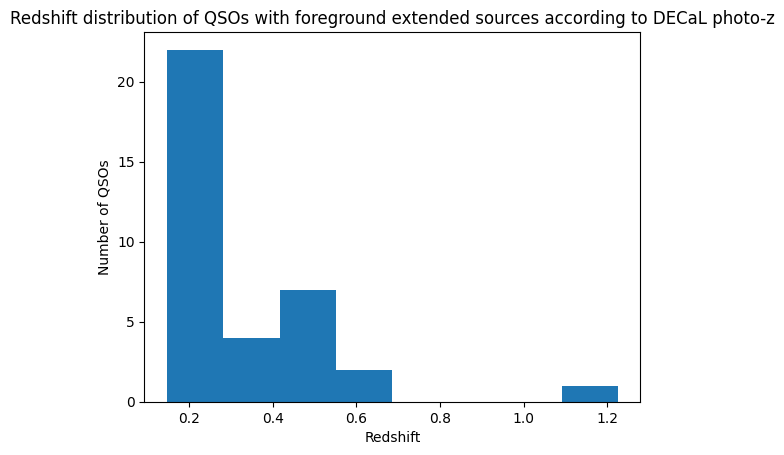

In [13]:
unique_qsos, unique_idx = np.unique(photoz_foreground['DESI_QSO_ID'], return_index=True)
print(f"Number of unique QSOs with foreground according to DECaL photo-z: {len(unique_qsos)}")

plt.hist(photoz_foreground['QSO_z'][unique_idx], bins='auto')
plt.xlabel("Redshift")
plt.ylabel("Number of QSOs")
plt.title("Redshift distribution of QSOs with foreground extended sources according to DECaL photo-z")
plt.show()

In [14]:
spec_client = SparclClient(announcement=False)

nebular_lines = {
    "[OII]3726": 3726.03,
    "[OII]3729": 3728.82,
    "Hb": 4861.33,
    "[OIII]4959": 4958.91,
    "[OIII]5007": 5006.84,
    "Ha": 6562.80,
    "[NII]6548": 6548.05,
    "[NII]6583": 6583.45,
    "[SII]6716": 6716.44,
    "[SII]6731": 6730.82,
}

def clip_qso_features(wave,flux, err,
                      z, lines, dv_clip=400):

    flux_clip = flux.copy()
    err_clip = err.copy()

    # ----- Mask nebular emission lines -----
    for lam0 in lines.values():

        lam_obs = lam0 * (1 + z)

        dlam = lam_obs * dv_clip / 3e5

        mask = np.abs(wave - lam_obs) < dlam

        flux_clip[mask] = np.nan
        err_clip[mask] = np.nan
        

    # ----- Mask deep absorption -----
    absorption_mask = flux < 0.8

    flux_clip[absorption_mask] = np.nan
    err_clip[absorption_mask] = np.nan


    return flux_clip, err_clip

def continuum_normalize(wave, flux, error, kernel_win=5, node_spacing=2.5):

    # Estimate pixel scale more robustly
    dw = np.median(np.diff(wave))
    kernel_size = int(kernel_win // dw)

    # Ensure odd kernel size
    if kernel_size % 2 == 0:
        kernel_size += 1
    if kernel_size < 3:
        kernel_size = 3

    # Median filter smoothing
    flux_med = medfilt(flux, kernel_size)

    # Residuals
    residuals = flux - flux_med

    # Continuum mask
    idx = (
        (error > 0) &
        (residuals / error > -1.5) &
        (residuals / error < 2.0)
    )

    # Guard against pathological cases
    if np.sum(idx) < 10:
        raise ValueError("Too few continuum points")

    # Initial continuum points
    wav_cont_init = wave[idx]
    cont_init = flux[idx]

    # Smooth again
    cont_med = medfilt(cont_init, kernel_size)

    # Interpolate continuum
    cont_interp = interp1d(
        wav_cont_init,
        cont_med,
        bounds_error=False,
        fill_value=(cont_med[0], cont_med[-1])
    )

    # Define nodes
    wave_nodes = np.arange(wave[0], wave[-1] + node_spacing, node_spacing)
    cont_nodes = cont_interp(wave_nodes)

    # Fit spline
    cont_spline = UnivariateSpline(wave_nodes, cont_nodes, s=0)

    # Normalize
    continuum = cont_spline(wave)
    flux_norm = flux / continuum
    error_norm = error / continuum

    return flux_norm, error_norm

def download_desi_spectrum(target_id, output_file, z):
    
    try:
        results = spec_client.retrieve_by_specid(
            specid_list=[int(target_id)],
            include=['specid', 'wavelength', 'flux', 'ivar']
        ).records

        if len(results) > 0:
            wave, flux, ivar = results[0].wavelength, results[0].flux, results[0].ivar

            with np.errstate(divide='ignore', invalid='ignore'):
                err = np.where(ivar > 0, 1/np.sqrt(ivar), np.nan)

            # Continuum normalize
            flux_norm, err_norm = continuum_normalize(wave, flux, err)

            # Clip QSO emission
            flux_clip, err_clip = clip_qso_features(wave, flux_norm, err_norm, z, nebular_lines) 
            
            tab = Table([wave, flux, err, flux_norm, err_norm, flux_clip, err_clip], names=['wavelength', 'flux', 'error', 'flux_norm', 'error_norm', 'flux_clip', 'error_clip'])
            tab.write(output_file, format='ascii.commented_header', overwrite=True)
            return tab
    except Exception as e:
        print(f"Error retrieving spectrum for target ID {target_id}: {e}")
        return Table(names=['wavelength', 'flux', 'error', 'flux_norm', 'error_norm', 'flux_clip', 'error_clip'], dtype=[float]*7)

In [15]:
os.makedirs("spectra/spectra_plots", exist_ok=True)
os.makedirs("spectra/data", exist_ok=True)

master_tab_qso_ids, table_idx = np.unique(matched_qso['DESI_ID'], return_index=True)
qso_zs = matched_qso['DESI_z'][table_idx]
qso_ra = matched_qso['ra'][table_idx]
qso_dec = matched_qso['dec'][table_idx]

for qso_id, z, ra, dec in tqdm.tqdm(zip(master_tab_qso_ids, qso_zs, qso_ra, qso_dec)):

    if os.path.isfile(f"desi_qso_cutouts/{qso_id}_cutout.jpeg"):
        continue
    else:
        # Make a cutout around the QSO and save it as a JPG
        fname = legacystamps.download(ra=ra, dec=dec,
                            mode='jpeg', bands='grz',
                            size=60*u.arcsec.to('deg'), ddir=os.path.abspath("desi_qso_cutouts"))
        
        basename = os.path.basename(fname)
        os.rename(fname, fname.replace(basename, f"{qso_id}_cutout.jpeg"))

        # First download the spectrum and save it to a file
        output_file = f"spectra/data/{qso_id}.dat"
        spec_tab = download_desi_spectrum(qso_id, output_file, z)

        # Plot if the spectrum was successfully downloaded
        if len(spec_tab) > 0:
            fig, ax = plt.subplots(2, 1, figsize=(20,10))

            # Just the raw spectrum and error
            rest_wave = spec_tab['wavelength'] / (1 + z)
            ax[0].step(spec_tab['wavelength'], spec_tab['flux'], label='Spectrum', color='black', lw=2)
            ax[0].step(spec_tab['wavelength'], spec_tab['error'], label='Error', color='red', ls="--")
            ax[0].set_xlabel("Wavelength (Angstrom)")
            ax[0].set_ylabel("Flux")
            # Create a second x-axis for rest wavelength and use rest_wave for the ticks
            # ax2 = ax[0].twiny()
            # ax2.set_xlim(ax[0].get_xlim()/(1+z))
            # ax2.set_xticks(ax[0].get_xticks()/(1+z))
            # ax2.set_xticklabels([f"{w:.0f}" for w in ax[0].get_xticks()/(1+z)])
            # ax2.set_xlabel("Rest Wavelength (Angstrom)")
            ax[0].set_title(f"DESI QSO ID: {qso_id}, z = {z:.4f}")

            # Continuum normalized and clipped spectrum
            med_error = np.nanmedian(spec_tab['error_norm'])
            ax[1].step(spec_tab['wavelength'], spec_tab['flux_clip'], label='Clipped Spectrum', color='black', lw=2)
            ax[1].step(spec_tab['wavelength'], 1-3*med_error+spec_tab['error_clip'], label='Clipped Error + const', color='red', ls="--")
            ax[1].set_xlabel("Wavelength (Angstrom)")
            ax[1].set_ylabel("Flux")
            ax[1].set_title(f"Continuum Normalized and Clipped Spectrum")
            ax[1].set_ylim(1 - 3*med_error, 1 + 20*med_error)
            ax[1].legend()
            plt.savefig(f"spectra/spectra_plots/{qso_id}_spectrum.png")
            plt.close()

0it [00:00, ?it/s]

URL to obtain cutout: https://www.legacysurvey.org/viewer/jpeg-cutout/?ra=121.475499&dec=11.242350&layer=ls-dr9&pixscale=0.262&bands=grz&size=229
24KB [00:00, 108.21KB/s]                        
Cutout saved to /mnt/popos/home/sunil/Desktop/FRB/gotoq/desi_qso_cutouts/legacystamps_121.475499_11.242350_ls-dr9.jpeg.


568it [00:15, 36.00it/s]

URL to obtain cutout: https://www.legacysurvey.org/viewer/jpeg-cutout/?ra=122.146335&dec=11.322052&layer=ls-dr9&pixscale=0.262&bands=grz&size=229
26KB [00:00, 52.75KB/s]                        
Cutout saved to /mnt/popos/home/sunil/Desktop/FRB/gotoq/desi_qso_cutouts/legacystamps_122.146335_11.322052_ls-dr9.jpeg.
URL to obtain cutout: https://www.legacysurvey.org/viewer/jpeg-cutout/?ra=228.560530&dec=11.189064&layer=ls-dr9&pixscale=0.262&bands=grz&size=229
25KB [00:01, 13.27KB/s]                        
Cutout saved to /mnt/popos/home/sunil/Desktop/FRB/gotoq/desi_qso_cutouts/legacystamps_228.560530_11.189064_ls-dr9.jpeg.


571it [00:30, 15.46it/s]

...

1308it [55:58,  3.12s/it]

URL to obtain cutout: https://www.legacysurvey.org/viewer/jpeg-cutout/?ra=229.646844&dec=-0.585172&layer=ls-dr9&pixscale=0.262&bands=grz&size=229
26KB [00:00, 114.82KB/s]                        
Cutout saved to /mnt/popos/home/sunil/Desktop/FRB/gotoq/desi_qso_cutouts/legacystamps_229.646844_-0.585172_ls-dr9.jpeg.


1309it [56:03,  3.70s/it]

URL to obtain cutout: https://www.legacysurvey.org/viewer/jpeg-cutout/?ra=59.405264&dec=-16.804384&layer=ls-dr9&pixscale=0.262&bands=grz&size=229
17KB [00:00, 280.52KB/s]              
Cutout saved to /mnt/popos/home/sunil/Desktop/FRB/gotoq/desi_qso_cutouts/legacystamps_59.405264_-16.804384_ls-dr9.jpeg.


1310it [56:05,  2.57s/it]
